In [2]:
import warnings
warnings.filterwarnings('ignore')
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))

from constants import REGION_TO_COUNTIES

In [3]:
# Loading updated county_profiles.csv
df = pd.read_csv(
    "../data/processed/county_profiles.csv"
)

print(df.shape)

df.head()

(47, 60)


,county,period,MOH 731_HIV_TB_OnART_15-19_(F)_HV03-24,MOH 731_HIV_TB_OnART_15-19_(M)_HV03-23,MOH 731_HIV_TB_OnART_20-24_(F)_HV03-26,MOH 731_HIV_TB_OnART_20-24_(M)_HV03-25,MOH 731_HIV_TB_OnART_25+_(F)_HV03-28,MOH 731_HIV_TB_OnART_25+_(M)_HV03-27,adults_on_art,art_total_males,...,iit_rate_female_pct,hts_positivity_rate,iit_rate_yoy_change,vls_rate_adult_yoy_change,art_coverage,care_gap_index,iit_rate,vls_rate,cluster,tier
0,Baringo,2025,82,70,164,92,3629,1701,5738,1863,...,0.153,0.006349,0,0,0.5,9.05,0.1530,0.9300,0,Critical
1,Bomet,2025,234,160,416,175,7745,3616,12346,3951,...,0.153,0.011902,0,0,0.5,9.14,0.1530,0.9305,0,Critical
2,Bungoma,2025,591,450,1235,400,20203,7717,30596,8567,...,0.091,0.011876,0,0,0.5,5.35,0.0895,0.9618,1,High
3,Busia,2025,543,467,940,425,23538,11203,37116,12095,...,0.091,0.012605,0,0,0.5,5.21,0.0895,0.9656,1,High
4,Elgeyo Marakwet,2025,83,68,149,55,3196,1368,4919,1491,...,0.153,0.007338,0,0,0.5,8.29,0.1530,0.9494,0,Critical


In [4]:
#validate required columns
df.columns.tolist()

['county',
 'period',
 'MOH 731_HIV_TB_OnART_15-19_(F)_HV03-24',
 'MOH 731_HIV_TB_OnART_15-19_(M)_HV03-23',
 'MOH 731_HIV_TB_OnART_20-24_(F)_HV03-26',
 'MOH 731_HIV_TB_OnART_20-24_(M)_HV03-25',
 'MOH 731_HIV_TB_OnART_25+_(F)_HV03-28',
 'MOH 731_HIV_TB_OnART_25+_(M)_HV03-27',
 'adults_on_art',
 'art_total_males',
 'art_total_females',
 'MOH 731_HTS_Tests _(F) (Including PMTCT)_ HV01-02',
 'MOH 731_HTS_Tests _(M)_ HV01-01',
 'hts_tested',
 'hts_tested_males',
 'hts_tested_females',
 'MOH 731_HTS_Positive_2-9 _(M)_ HV01-06',
 'MOH 731_HTS_Positive_2-9 _(F) (Including PMTCT)_ HV01-07',
 'MOH 731_HTS_Positive_10-14 _(F) (Including PMTCT)_HV01-09',
 'MOH 731_HTS_Positive_10-14 _(M)_HV01-08',
 'MOH 731_HTS_Positive_15-19 _(F) (Including PMTCT)_HV01-11',
 'MOH 731_HTS_Positive_15-19 _(M)_HV01-10',
 'MOH 731_HTS_Positive_20-24 _(M)_HV01-12',
 'MOH 731_HTS_Positive_20-24 _(F) (Including PMTCT)_HV01-13',
 'MOH 731_HTS_Positive_25+ _(M)_HV01-14',
 'MOH 731_HTS_Positive_25+ _(F) (Including PMTCT)_H

#### Scenario A Flat Prediction

In [5]:
# Aggregate Per-Tier Rates
tier_rates = (
    df.groupby("tier")[
        [
            "iit_rate",
            "vls_rate_adult",
            "care_gap_index"
        ]
    ]
    .mean()
    .reset_index()
)

tier_rates

,tier,iit_rate,vls_rate_adult,care_gap_index
0,Critical,0.153000,0.942107,8.631429
1,High,0.094924,0.961208,5.597600
2,Low,0.092600,0.813600,11.370000
3,Moderate,0.094107,0.905257,7.761429


In [6]:
# Creating Flat Prediction Dataset
prediction_rows = []

for _, row in tier_rates.iterrows():

    for year in range(2025, 2031):

        prediction_rows.append({

            "tier": row["tier"],
            "year": year,
            "iit_rate": row["iit_rate"],
            "vls_rate_adult": row["vls_rate_adult"],
            "care_gap_index": row["care_gap_index"]
        })

prediction_df = pd.DataFrame(
    prediction_rows
)

prediction_df.head()

,tier,year,iit_rate,vls_rate_adult,care_gap_index
0,Critical,2025,0.153,0.942107,8.631429
1,Critical,2026,0.153,0.942107,8.631429
2,Critical,2027,0.153,0.942107,8.631429
3,Critical,2028,0.153,0.942107,8.631429
4,Critical,2029,0.153,0.942107,8.631429


Flat projection Assumption: Since only 2025 data exists all future years remains constant

In [7]:
# Save prediction CSVs
for tier in prediction_df["tier"].unique():

    tier_df = prediction_df[
        prediction_df["tier"] == tier
    ]

    filename = (
        f"../data/processed/"
        f"prediction_{tier.lower()}.csv"
    )

    tier_df.to_csv(
        filename,
        index=False
    )

print("Prediction CSVs saved successfully")

Prediction CSVs saved successfully


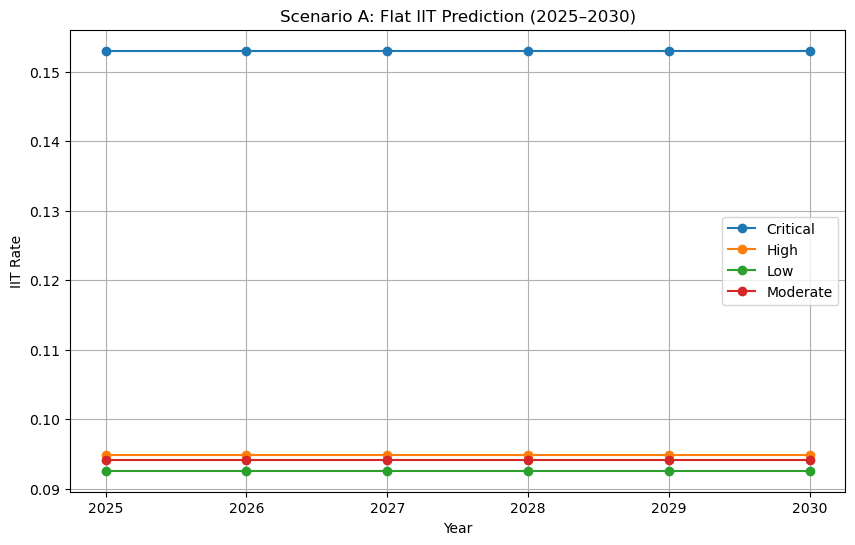

In [8]:
#Plot IIT Predictions
plt.figure(figsize=(10, 6))

for tier in prediction_df["tier"].unique():

    tier_df = prediction_df[
        prediction_df["tier"] == tier
    ]

    plt.plot(
        tier_df["year"],
        tier_df["iit_rate"],
        marker="o",
        label=tier
    )

plt.title(
    "Scenario A: Flat IIT Prediction (2025–2030)"
)

plt.xlabel("Year")
plt.ylabel("IIT Rate")

plt.legend()

plt.grid(True)

plt.show()


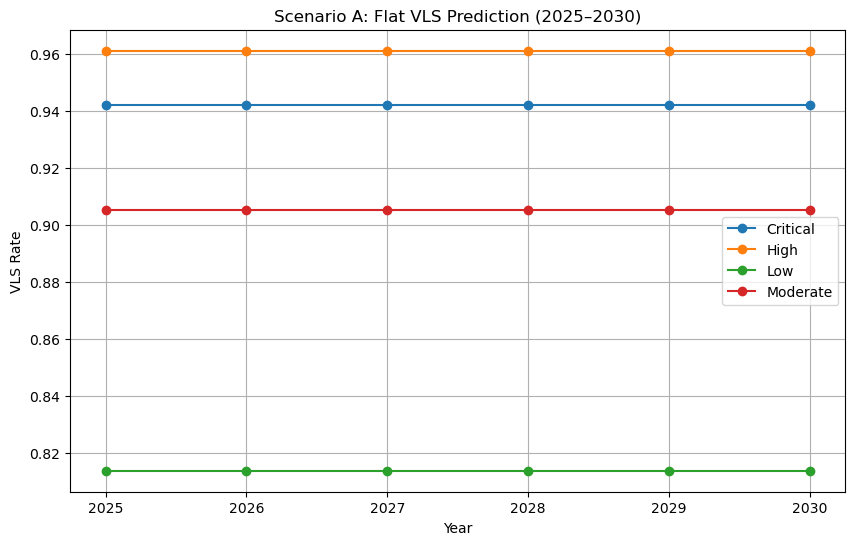

In [9]:
# Plot VLS Predictions
plt.figure(figsize=(10, 6))

for tier in prediction_df["tier"].unique():

    tier_df = prediction_df[
        prediction_df["tier"] == tier
    ]

    plt.plot(
        tier_df["year"],
        tier_df["vls_rate_adult"],
        marker="o",
        label=tier
    )

plt.title(
    "Scenario A: Flat VLS Prediction (2025–2030)"
)

plt.xlabel("Year")
plt.ylabel("VLS Rate")

plt.legend()

plt.grid(True)

plt.show()

#### Component B: County comparision

In [10]:
#Rank counties by IIT
iit_ranking = (
    df[
        ["county", "iit_rate"]
    ]
    .sort_values(
        "iit_rate",
        ascending=False
    )
)

iit_ranking.head()

,county,iit_rate
0,Baringo,0.153
11,Kericho,0.153
43,Uasin Gishu,0.153
42,Turkana,0.153
41,Trans Nzoia,0.153


In [11]:
# Rank counties by VLS
vls_ranking = (
    df[
        ["county", "vls_rate_adult"]
    ]
    .sort_values(
        "vls_rate_adult",
        ascending=True
    )
)

vls_ranking.head()

,county,vls_rate_adult
20,Lamu,0.8136
39,Tana River,0.8893
37,Siaya,0.8947
8,Isiolo,0.9017
38,Taita Taveta,0.9046


In [12]:
# Rank Counties by CGI
cgi_ranking = (
    df[
        ["county", "care_gap_index"]
    ]
    .sort_values(
        "care_gap_index",
        ascending=False
    )
)

cgi_ranking.head()

,county,care_gap_index
20,Lamu,11.37
36,Samburu,9.78
46,West Pokot,9.69
42,Turkana,9.21
1,Bomet,9.14


In [13]:
#Worst and Best Counties
worst_5 = cgi_ranking.head(5)

best_5 = cgi_ranking.tail(5)

print("Top 5 Worst Counties")
display(worst_5)

print("Top 5 Best Counties")
display(best_5)

Top 5 Worst Counties


,county,care_gap_index
20,Lamu,11.37
36,Samburu,9.78
46,West Pokot,9.69
42,Turkana,9.21
1,Bomet,9.14


Top 5 Best Counties


,county,care_gap_index
14,Kirinyaga,5.09
35,Nyeri,5.08
15,Kisii,5.02
45,Wajir,4.51
23,Mandera,4.50


#### Create Region Mapping

In [14]:
county_to_region = {}

for region, counties in REGION_TO_COUNTIES.items():

    for county in counties:

        county_to_region[county] = region

In [15]:
# Add region column
df["region"] = df["county"].map(
    county_to_region
)

df[
    ["county", "region"]
].head()

,county,region
0,Baringo,Rift Valley
1,Bomet,Rift Valley
2,Bungoma,Western
3,Busia,Western
4,Elgeyo Marakwet,Rift Valley


In [16]:
# Save County Comparision CSVs
comparison_df = df[
    [
        "county",
        "region",
        "tier",
        "iit_rate",
        "vls_rate_adult",
        "care_gap_index"
    ]
]

comparison_df.to_csv(
    "../data/processed/county_comparison.csv",
    index=False
)

print(
    "county_comparison.csv saved successfully"
)

county_comparison.csv saved successfully


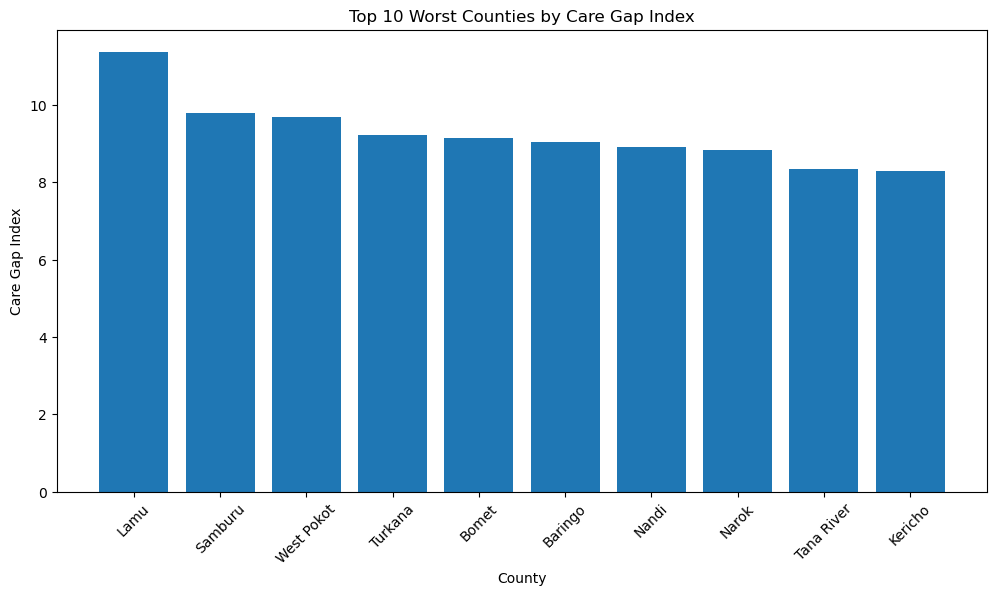

In [17]:
# Top 10 Worst Counties by CGI 
top10 = (
    cgi_ranking
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top10["county"],
    top10["care_gap_index"]
)

plt.xticks(rotation=45)

plt.title(
    "Top 10 Worst Counties by Care Gap Index"
)

plt.xlabel("County")
plt.ylabel("Care Gap Index")

plt.show()

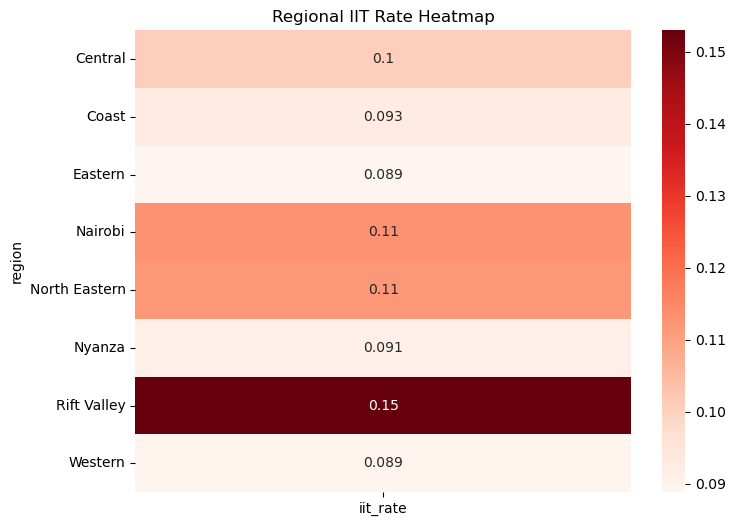

In [18]:
# Regional IIT Heatmap
regional_iit = (
    df.groupby("region")[
        "iit_rate"
    ]
    .mean()
    .reset_index()
)

heatmap_data = regional_iit.pivot_table(
    values="iit_rate",
    index="region"
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="Reds"
)

plt.title(
    "Regional IIT Rate Heatmap"
)

plt.show()

In [19]:
# Final validation
print(df.shape)

print(prediction_df.shape)

print(comparison_df.shape)

(47, 61)
(24, 5)
(47, 6)
